In [4]:
# Basic imports
import pandas as pd
import numpy as np

# ML imports
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Models
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

import warnings
warnings.filterwarnings('ignore')

print("✅ All libraries imported successfully.")




✅ All libraries imported successfully.


In [17]:
import pandas as pd
import requests
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import seaborn as sns

In [23]:
from bs4 import BeautifulSoup
import requests
import pandas as pd

url = "https://people.dbmi.columbia.edu/~friedma/Projects/DiseaseSymptomKB/index.html"

response = requests.get(url)
soup = BeautifulSoup(response.text, 'html.parser')  # built-in parser

# Extract the main disease-symptom table
table = soup.find_all('table')[0]

rows = []
for tr in table.find_all('tr'):
    cols = [td.text.strip() for td in tr.find_all('td')]
    if len(cols) == 3:
        rows.append(cols)

df = pd.DataFrame(rows, columns=['Disease', 'Symptom', 'Frequency'])
print(df.head())


                                 Disease                         Symptom  \
0                                Disease  Count of Disease\n  Occurrence   
1  UMLS:C0020538_hypertensive\n  disease                            3363   
2                                                                          
3                                                                          
4                                                                          

                              Frequency  
0                               Symptom  
1           UMLS:C0008031_pain\n  chest  
2  UMLS:C0392680_shortness\n  of breath  
3               UMLS:C0012833_dizziness  
4                UMLS:C0004093_asthenia  


In [24]:
# Save the scraped DataFrame as CSV
df.to_csv("Disease_Symptom_KB.csv", index=False)
print("Saved as 'Disease_Symptom_KB.csv'")


Saved as 'Disease_Symptom_KB.csv'


In [33]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load scraped & cleaned CSV
df = pd.read_csv("Generated_Disease_Symptom.csv")

# First, aggregate to one row per disease
disease_symptoms_dict = {}

for _, row in df.iterrows():
    disease = row['prognosis']
    # Collect all symptoms present for this disease
    symptoms_present = [col for col in df.columns if col != 'prognosis' and row[col] == 1]
    
    if disease not in disease_symptoms_dict:
        disease_symptoms_dict[disease] = set()
    
    disease_symptoms_dict[disease].update(symptoms_present)

# Get all unique symptoms
all_symptoms = sorted({symptom for symptoms in disease_symptoms_dict.values() for symptom in symptoms})

# Build aggregated binary dataset (one row per disease)
data_rows = []
for disease, symptoms in disease_symptoms_dict.items():
    row = [1 if symptom in symptoms else 0 for symptom in all_symptoms]
    row.append(disease)
    data_rows.append(row)

df_agg = pd.DataFrame(data_rows, columns=all_symptoms + ['prognosis'])

# Split diseases into train/test
diseases = df_agg['prognosis'].tolist()
train_diseases, test_diseases = train_test_split(diseases, test_size=0.2, random_state=42)

df_train = df_agg[df_agg['prognosis'].isin(train_diseases)]
df_test = df_agg[df_agg['prognosis'].isin(test_diseases)]

# Save
df_train.to_csv("Prototype-1.csv", index=False)
df_test.to_csv("Prototype.csv", index=False)

print("Saved ML-ready train/test CSVs with one row per disease")
print(f"Train shape: {df_train.shape}, Test shape: {df_test.shape}")


Saved ML-ready train/test CSVs with one row per disease
Train shape: (119, 105), Test shape: (30, 105)


In [34]:
# ================= Decision Tree Tuning =================
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Load dataset
df = pd.read_csv("Prototype.csv")

# Split into features and labels
X = df.drop("prognosis", axis=1)
y = df["prognosis"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Define model
dt = DecisionTreeClassifier(random_state=42)

# Define hyperparameter grid
param_grid = {
    "criterion": ["gini", "entropy", "log_loss"],
    "max_depth": [None, 10, 20, 30, 50],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5]
}

# Grid search with 5-fold CV
grid = GridSearchCV(dt, param_grid, cv=5, scoring="accuracy", n_jobs=-1, verbose=2)
grid.fit(X_train, y_train)

# Evaluate best model
best_dt = grid.best_estimator_
y_pred = best_dt.predict(X_test)

print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)
print("Test Accuracy:", accuracy_score(y_test, y_pred))


Fitting 5 folds for each of 135 candidates, totalling 675 fits
Best Parameters: {'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV Accuracy: 1.0
Test Accuracy: 1.0


In [35]:
# ================= Random Forest Tuning =================
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Load dataset
df = pd.read_csv("Prototype.csv")

# Split into features and labels
X = df.drop("prognosis", axis=1)
y = df["prognosis"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Define model
rf = RandomForestClassifier(random_state=42)

# Define hyperparameter grid
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [None, 10, 20, 30],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "bootstrap": [True, False]
}

# Grid search with 3-fold CV (to save time)
grid = GridSearchCV(rf, param_grid, cv=3, scoring="accuracy", n_jobs=-1, verbose=2)
grid.fit(X_train, y_train)

# Evaluate best model
best_rf = grid.best_estimator_
y_pred = best_rf.predict(X_test)

print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)
print("Test Accuracy:", accuracy_score(y_test, y_pred))


Fitting 3 folds for each of 216 candidates, totalling 648 fits
Best Parameters: {'bootstrap': True, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}
Best CV Accuracy: 1.0
Test Accuracy: 1.0


In [36]:
# ================= Support Vector Machine (RBF) Tuning =================
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

# Load dataset
df = pd.read_csv("Prototype.csv")

# Split into features and labels
X = df.drop("prognosis", axis=1)
y = df["prognosis"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Define model
svm = SVC(probability=True)

# Define parameter grid for tuning
param_grid = {
    "C": [0.1, 1, 10],
    "gamma": [1, 0.1, 0.01],
    "kernel": ["rbf"]
}

# Perform grid search
grid = GridSearchCV(svm, param_grid, cv=3, scoring="accuracy", n_jobs=-1, verbose=2)
grid.fit(X_train, y_train)

# Evaluate best model
best_svm = grid.best_estimator_
y_pred = best_svm.predict(X_test)

print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)
print("Test Accuracy:", accuracy_score(y_test, y_pred))


Fitting 3 folds for each of 9 candidates, totalling 27 fits
Best Parameters: {'C': 0.1, 'gamma': 1, 'kernel': 'rbf'}
Best CV Accuracy: 1.0
Test Accuracy: 1.0


In [37]:
# ================= K-Nearest Neighbors (KNN) Tuning =================
import pandas as pd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Load dataset
df = pd.read_csv("Prototype.csv")

# Split into features and labels
X = df.drop("prognosis", axis=1)
y = df["prognosis"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Define model
knn = KNeighborsClassifier()

# Define parameter grid
param_grid = {
    "n_neighbors": [3, 5, 7, 9],
    "weights": ["uniform", "distance"],
    "metric": ["euclidean", "manhattan"]
}

# Perform grid search
grid = GridSearchCV(knn, param_grid, cv=3, scoring="accuracy", n_jobs=-1, verbose=2)
grid.fit(X_train, y_train)

# Evaluate best model
best_knn = grid.best_estimator_
y_pred = best_knn.predict(X_test)

print("Best Parameters:", grid.best_params_)
print("Best CV Accuracy:", grid.best_score_)
print("Test Accuracy:", accuracy_score(y_test, y_pred))


Fitting 3 folds for each of 16 candidates, totalling 48 fits
Best Parameters: {'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}
Best CV Accuracy: 1.0
Test Accuracy: 1.0


In [39]:
# ================= Naive Bayes Evaluation =================
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score

# Load dataset
df = pd.read_csv("Prototype.csv")

# Split into features and labels
X = df.drop("prognosis", axis=1)
y = df["prognosis"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Define and train model
nb = GaussianNB()
nb.fit(X_train, y_train)

# Evaluate
y_pred = nb.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)

print("Model: Naive Bayes")
print("Test Accuracy:", test_acc)


Model: Naive Bayes
Test Accuracy: 1.0


In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score

# Define parameter grid
param_grid = {
    'C': [0.01, 0.1, 1, 10],
    'solver': ['lbfgs', 'liblinear'],
    'max_iter': [100, 200, 500]
}

# Model and GridSearch
lr = LogisticRegression()
grid_search = GridSearchCV(lr, param_grid, cv=3, scoring='accuracy', verbose=1)
grid_search.fit(X_train, y_train)

# Best model
best_lr = grid_search.best_estimator_

print("Best Parameters:", grid_search.best_params_)
print("Best CV Accuracy:", grid_search.best_score_)

# Test Accuracy
y_pred = best_lr.predict(X_test)
test_acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", test_acc)


Fitting 3 folds for each of 24 candidates, totalling 72 fits
Best Parameters: {'C': 0.01, 'max_iter': 100, 'solver': 'lbfgs'}
Best CV Accuracy: 1.0
Test Accuracy: 1.0



=== Model Comparison ===
                 Model  CV Accuracy  Test Accuracy
0        Decision Tree          1.0            1.0
1        Random Forest          1.0            1.0
2                  SVM          1.0            1.0
3                  KNN          1.0            1.0
4          Naive Bayes          1.0            1.0
5  Logistic Regression          1.0            1.0


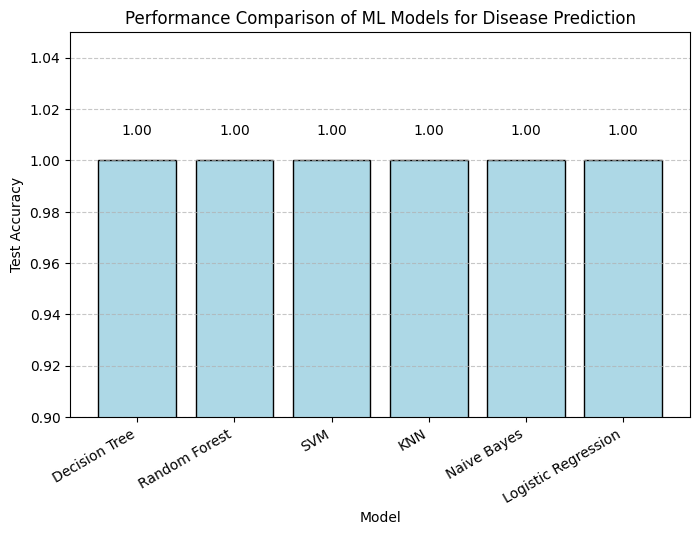

In [41]:
import pandas as pd
import matplotlib.pyplot as plt

# Results summary
results = {
    "Model": [
        "Decision Tree",
        "Random Forest",
        "SVM",
        "KNN",
        "Naive Bayes",
        "Logistic Regression"
    ],
    "CV Accuracy": [1.0, 1.0, 1.0, 1.0, 1.0, 1.0],
    "Test Accuracy": [1.0, 1.0, 1.0, 1.0, 1.0, 1.0]
}

df_results = pd.DataFrame(results)

# Display results
print("\n=== Model Comparison ===")
print(df_results)

# Plot
plt.figure(figsize=(8,5))
bars = plt.bar(df_results["Model"], df_results["Test Accuracy"], color='lightblue', edgecolor='black')
plt.title("Performance Comparison of ML Models for Disease Prediction")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.ylim(0.9, 1.05)
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Add accuracy labels above bars
for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval + 0.01, f"{yval:.2f}", ha='center', fontsize=10)

plt.show()


                 Model Accuracy  \
0        Decision Tree      1.0   
1        Random Forest      1.0   
2                  SVM      1.0   
3                  KNN      1.0   
4          Naive Bayes      1.0   
5  Logistic Regression      1.0   

                                         Best Params  
0  {'criterion': 'entropy', 'max_depth': None, 'm...  
1  {'bootstrap': True, 'max_depth': None, 'min_sa...  
2            {'C': 0.1, 'gamma': 1, 'kernel': 'rbf'}  
3  {'metric': 'euclidean', 'n_neighbors': 3, 'wei...  
4                                 Default Parameters  
5    {'C': 0.01, 'max_iter': 100, 'solver': 'lbfgs'}  


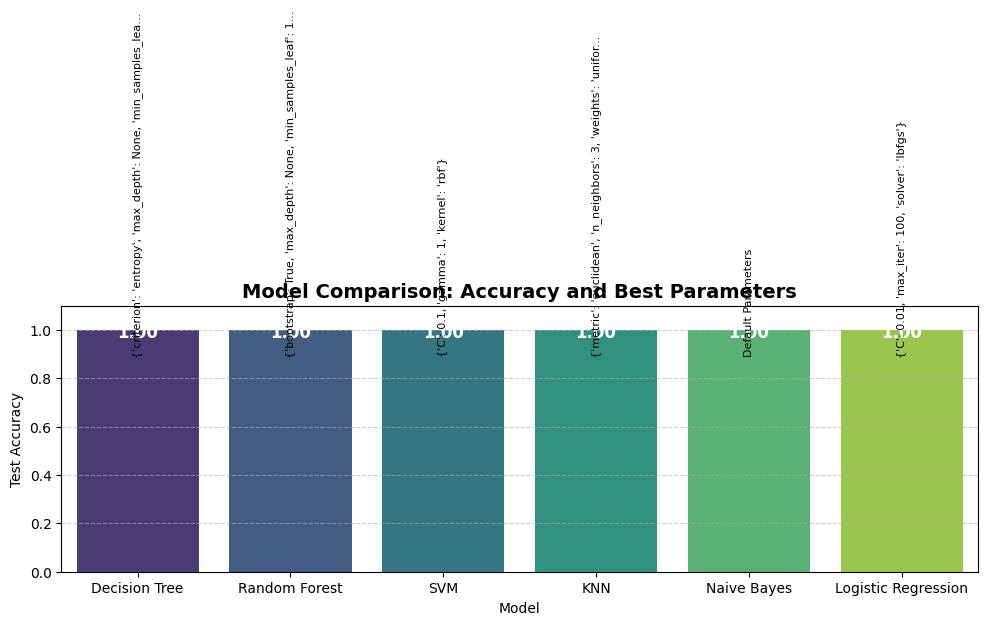

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Dictionary of your model results
results = {
    'Decision Tree': {
        'Accuracy': 1.0,
        'Best Params': "{'criterion': 'entropy', 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2}"
    },
    'Random Forest': {
        'Accuracy': 1.0,
        'Best Params': "{'bootstrap': True, 'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}"
    },
    'SVM': {
        'Accuracy': 1.0,
        'Best Params': "{'C': 0.1, 'gamma': 1, 'kernel': 'rbf'}"
    },
    'KNN': {
        'Accuracy': 1.0,
        'Best Params': "{'metric': 'euclidean', 'n_neighbors': 3, 'weights': 'uniform'}"
    },
    'Naive Bayes': {
        'Accuracy': 1.0,
        'Best Params': 'Default Parameters'
    },
    'Logistic Regression': {
        'Accuracy': 1.0,
        'Best Params': "{'C': 0.01, 'max_iter': 100, 'solver': 'lbfgs'}"
    }
}

# Convert dictionary to DataFrame
df_results = pd.DataFrame(results).T.reset_index().rename(columns={'index': 'Model'})
print(df_results)

# --- Visualization ---
plt.figure(figsize=(10, 6))
sns.barplot(data=df_results, x='Model', y='Accuracy', palette='viridis')

# Annotate accuracy values and best parameters
for i, row in enumerate(df_results.itertuples()):
    plt.text(i, row.Accuracy - 0.03, f"{row.Accuracy:.2f}", ha='center', color='white', fontsize=12, fontweight='bold')
    plt.text(i, row.Accuracy - 0.1, row._3[:60] + '...' if len(row._3) > 60 else row._3, 
             ha='center', color='black', fontsize=8, rotation=90)

plt.title('Model Comparison: Accuracy and Best Parameters', fontsize=14, fontweight='bold')
plt.ylabel('Test Accuracy')
plt.ylim(0, 1.1)
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()
